# 1. Текстовое описание набора данных
В качестве набора данных мы будем использовать набор данных по определению вида вина по его составу и характеритикам - https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data

Датасет включает в себя 13 параметров представленных числами:

* Alcohol - содержание алкоголя
* Malic acid - содержание яблочной кислоты
* Ash - минеральный остаток оставшийся в ходе сжигания остатка после испарения вина
* Alcalinity of ash - щелочность минерального остатка
* Magnesium - содержание магния
* Total phenols - общее количество фенолов
* Flavanoids - содержание флаваноидов
* Nonflavanoid phenols - содержание нефлаваноидовыъ фенолов
* Proanthocyanins - содержание Проантоцианидины
* Color intensity - интенсивность цвета
* Hue - отеннок
* OD280/OD315 of diluted wines - Оптическая плотность при 280 нм и 315 нм разбавленных вин
* Proline - содержание пролина


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")

In [2]:
from sklearn.datasets import load_wine
wine = load_wine()

wine_df = pd.DataFrame(data= np.c_[wine['data'], wine['target']],
                     columns= list(wine['feature_names']) + ['target'])

display(wine_df.head())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0.0


In [3]:
# Проверка на пустые значения
print(wine_df.isnull().sum())

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


## 2. Пропусков в датасете нет, как и категориальных признаков поэтому можно сразу рабоать с данными, но сначала отнормируем данные

In [4]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X = std_scaler.fit_transform(wine.data)
Y = wine.target

## 3. Разделим исходный набор данных на обучающую и тестовую выборки

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=123, stratify=Y)

print(f"Размер обучающей выборки: {X_train.shape}, {y_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}, {y_test.shape}")

Размер обучающей выборки: (124, 13), (124,)
Размер тестовой выборки: (54, 13), (54,)


## 4. Обучение модели КНН с произвольным гиперпараметром K

In [6]:
from sklearn.neighbors import KNeighborsClassifier

# Создаем объект классификатора с произвольным K=123
knn_base = KNeighborsClassifier(n_neighbors=123)
knn_base.fit(X_train, y_train)

# Делаем предсказания на тестовой выборке
y_pred_base = knn_base.predict(X_test)

# Оценка качества базовой модели

1. Accuracy
2. Classification report
3. Confusion Matrix для визуализации ложных срабатываний и пропусков.

Accuracy базовой модели (K=13): 0.9815

Отчет о классификации:
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



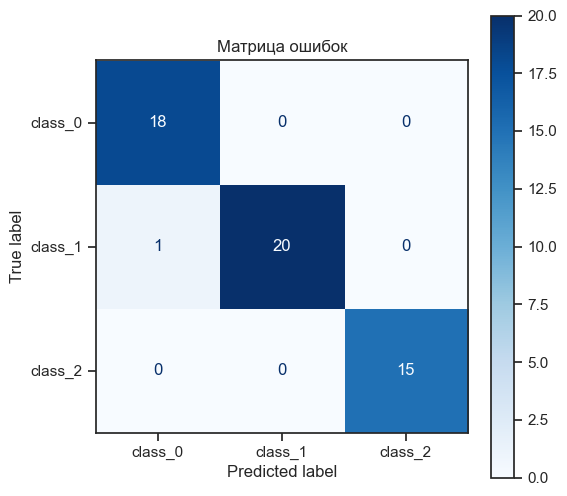

In [7]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay 

# 1. Метрика Accuracy
acc_base = accuracy_score(y_test, y_pred_base)
print(f"Accuracy базовой модели (K=123): {acc_base:.4f}\n")

# 2. Precision, Recall, F1-score
print("Отчет о классификации:")
print(classification_report(y_test, y_pred_base, target_names=wine.target_names))

# 3. Матрица ошибок
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(
    knn_base, X_test, y_test, 
    display_labels=wine.target_names, 
    cmap=plt.cm.Blues, ax=ax
)

plt.title("Матрица ошибок")
plt.show()

## 5. Подбор гиперпараметров и кросс-валидация

Используем 2 стратегии кросс-валидации:

* StratifiedKFold - разбивает выборку так, чтобы сохранялся баланс классов. Будем использовать её вместе с GridSearchCV
* RepeatedKFold - повторяет обычный K-Fold несколько раз. Будем использовать её вместе с RandomizedSearchCV

In [8]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold, RepeatedKFold

# переберем нечетные значения K от 1 до 50
n_range = np.array(range(1, 50, 2))
tuned_parameters = [{'n_neighbors': n_range}]

# 1-я Стратегия CV
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Поиск по решетке
clf_gs = GridSearchCV(KNeighborsClassifier(), tuned_parameters, 
                      cv=cv_stratified, scoring='accuracy')

# Обучаем на всем наборе X_train
clf_gs.fit(X_train, y_train)

print("GridSearchCV - Лучшее значение K:", clf_gs.best_params_)
print("GridSearchCV - Лучшее значение Accuracy на кросс-валидации:", clf_gs.best_score_)

GridSearchCV - Лучшее значение K: {'n_neighbors': np.int64(15)}
GridSearchCV - Лучшее значение Accuracy на кросс-валидации: 0.976


In [9]:
# 2-я Стратегия CV
cv_repeated = RepeatedKFold(n_splits=5, n_repeats=3, random_state=123)

# Случайный поиск
clf_rs = RandomizedSearchCV(KNeighborsClassifier(), tuned_parameters, 
                            cv=cv_repeated, scoring='accuracy', 
                            n_iter=10,
                            random_state=123)

clf_rs.fit(X_train, y_train)

print("RandomizedSearchCV - Лучшее значение K:", clf_rs.best_params_)
print("RandomizedSearchCV - Лучшее значение Accuracy на кросс-валидации:", clf_rs.best_score_)

RandomizedSearchCV - Лучшее значение K: {'n_neighbors': np.int64(23)}
RandomizedSearchCV - Лучшее значение Accuracy на кросс-валидации: 0.9704444444444444


## 6. Оценка качества оптимальной модели и сравнение

Accuracy 1й модели (K=13): 0.9815
Accuracy оптимальной модели (K=15): 0.9815

Отчет о классификации оптимальной модели:
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



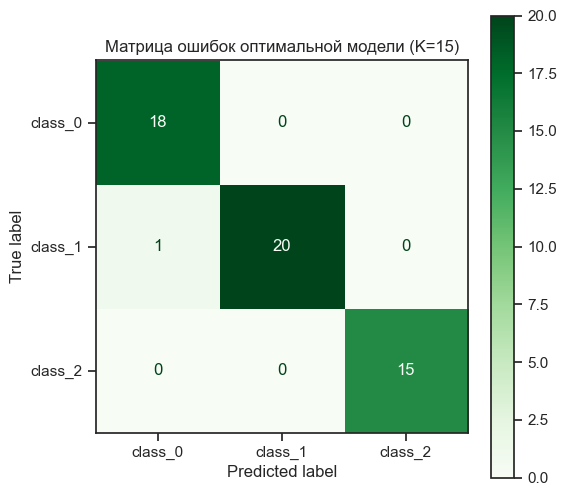

In [10]:
best_knn = clf_gs.best_estimator_

# Делаем предсказания
y_pred_best = best_knn.predict(X_test)

# Считаем новую Accuracy
acc_best = accuracy_score(y_test, y_pred_best)

print(f"Accuracy 1й модели (K=123): {acc_base:.4f}")
print(f"Accuracy оптимальной модели (K={clf_gs.best_params_['n_neighbors']}): {acc_best:.4f}\n")

print("Отчет о классификации оптимальной модели:")
print(classification_report(y_test, y_pred_best, target_names=wine.target_names))

# Отрисуем матрицу ошибок для оптимальной модели
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(
    best_knn, X_test, y_test, 
    display_labels=wine.target_names, 
    cmap=plt.cm.Greens, ax=ax
)
plt.title(f"Матрица ошибок оптимальной модели (K={clf_gs.best_params_['n_neighbors']})")
plt.show()

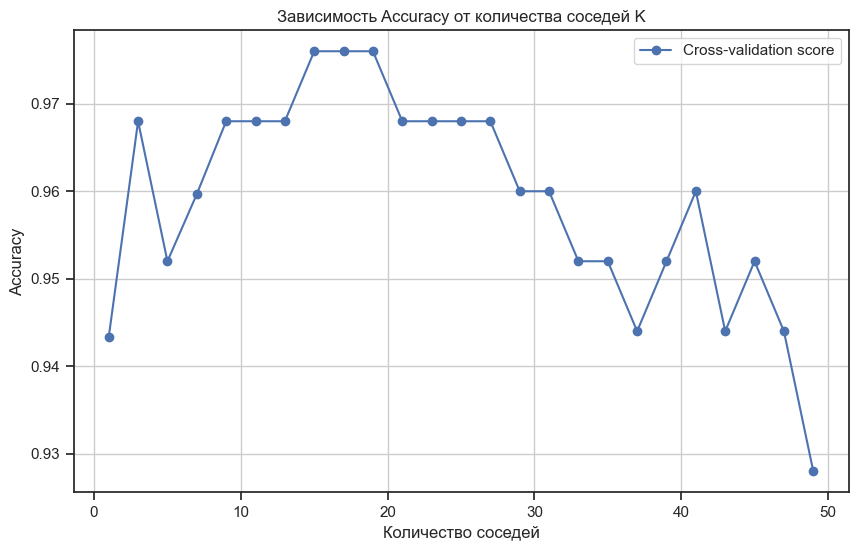

In [11]:
# Извлечем средние значения метрик на кросс-валидации из GridSearchCV
test_scores = clf_gs.cv_results_['mean_test_score']

plt.figure(figsize=(10, 6))
plt.plot(n_range, test_scores, marker='o', color='b', label='Cross-validation score')
plt.title("Зависимость Accuracy от количества соседей K")
plt.xlabel("Количество соседей")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()
plt.show()